In [2]:
# Linear regression with Transformer encoder

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import time


In [2]:
# --- 1. Generate Data ---

# Set seed for reproducibility
torch.manual_seed(42)

# --- 1. Generate synthetic data ---
input_dim = 4
n_samples = 1000
batch_size = 100

true_w = torch.randn(input_dim)
true_b = 0.5

X = torch.randn(n_samples, input_dim)
y = X @ true_w + true_b + 0.1 * torch.randn(n_samples)  # Linear function + noise

# Train/test split
train_n = int(round(0.8 * n_samples, 0))
train_X, test_X = X[:train_n], X[train_n:]
train_y, test_y = y[:train_n], y[train_n:]

train_loader = DataLoader(TensorDataset(train_X, train_y), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(test_X, test_y), batch_size=batch_size)


In [8]:
train_X.shape

torch.Size([800, 4])

In [14]:
# --- 2. Transformer Model for Regression ---
class TransformerForLinearRegression(nn.Module):
    def __init__(self, input_dim, d_model=16, nhead=2, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output = nn.Linear(d_model, 1)
    
    def forward(self, x):
        # x: (batch_size, input_dim)
        x = x.unsqueeze(-1)  # (batch_size, input_dim, 1)
        x = self.embedding(x)  # (batch_size, input_dim, d_model)
        x = x.permute(1, 0, 2)  # (seq_len, batch_size, d_model)
        x = self.transformer(x)  # (seq_len, batch_size, d_model)
        x = x.mean(dim=0)  # Mean pooling: (batch_size, d_model)
        return self.output(x).squeeze(-1)  # (batch_size,)

Comment: 
* nn.TransformerEncoderLayer(...): defines a single block of multi-head attention + feed-forward + normalization.
* nn.TransformerEncoder(...): stacks multiple such layers (num_layers times).
* Both are needed if you want multiple encoder layers

In [15]:
# Linear baseline
class LinearRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x).squeeze(-1)


In [16]:
# --- 3. Train Function ---
def train_model(model, train_loader, test_loader, n_epochs=30, lr = 1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses = []

    start = time.time()
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        train_losses.append(total_loss / len(train_loader.dataset))
        if (epoch%10 == 0): print(f"Epoch {epoch+1}/{n_epochs} | Loss: {total_loss:.4f}")
    end = time.time()

    # Evaluate
    model.eval()
    with torch.no_grad():
        preds, targets = [], []
        for xb, yb in test_loader:
            pred = model(xb)
            preds.append(pred)
            targets.append(yb)
        preds = torch.cat(preds)
        targets = torch.cat(targets)
        test_mse = F.mse_loss(preds, targets).item()

    return train_losses, test_mse, preds, targets, end - start

Training Transformer...


/opt/anaconda3/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch 1/100 | Loss: 456.4676
Epoch 11/100 | Loss: 30.9212
Epoch 21/100 | Loss: 29.0507
Epoch 31/100 | Loss: 29.2680
Epoch 41/100 | Loss: 28.0278
Epoch 51/100 | Loss: 27.6591
Epoch 61/100 | Loss: 28.6405
Epoch 71/100 | Loss: 28.4581
Epoch 81/100 | Loss: 27.1014
Epoch 91/100 | Loss: 27.8052


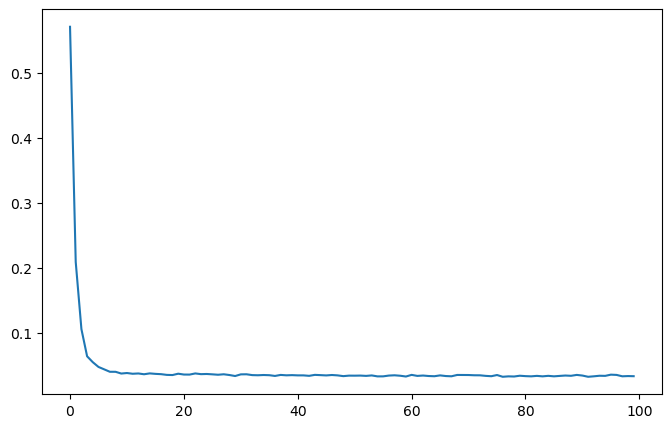

In [7]:
# --- 4. Run Training ---
print("Training Transformer...")
transformer_model = TransformerForLinearRegression(input_dim=input_dim)
transformer_losses, transformer_mse, transformer_preds, transformer_targets, transformer_time = train_model(transformer_model, train_loader, test_loader,n_epochs = 100)

plt.figure(figsize=(8, 5))
plt.plot(transformer_losses, label="Transformer")
plt.show()


Training Linear Regression...
Epoch 1/100 | Loss: 416.5270
Epoch 11/100 | Loss: 8.0280
Epoch 21/100 | Loss: 7.5930
Epoch 31/100 | Loss: 7.6027
Epoch 41/100 | Loss: 7.6366
Epoch 51/100 | Loss: 7.6279
Epoch 61/100 | Loss: 7.6117
Epoch 71/100 | Loss: 7.6810
Epoch 81/100 | Loss: 7.6317
Epoch 91/100 | Loss: 7.6401

Transformer Test MSE: 0.0267, Time: 8.84s
Linear     Test MSE: 0.0110, Time: 0.36s


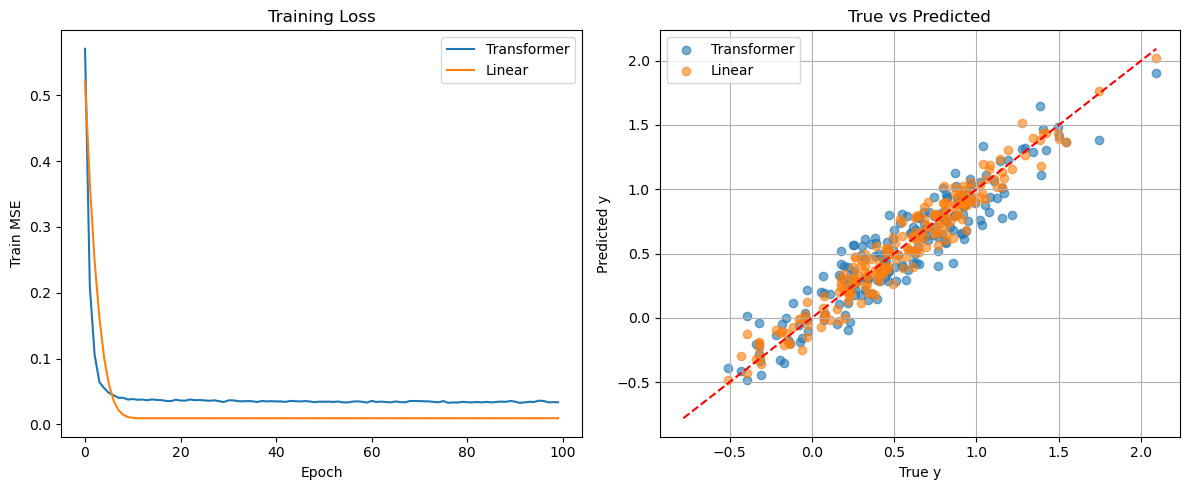

In [9]:
print("\nTraining Linear Regression...")
linear_model = LinearRegression(input_dim=input_dim)
linear_losses, linear_mse, linear_preds, linear_targets, linear_time = train_model(linear_model, train_loader, test_loader, n_epochs = 100, lr = 1e-2)

# --- 5. Print and Plot Results ---
print(f"\nTransformer Test MSE: {transformer_mse:.4f}, Time: {transformer_time:.2f}s")
print(f"Linear     Test MSE: {linear_mse:.4f}, Time: {linear_time:.2f}s")

# Plot losses
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(transformer_losses, label="Transformer")
plt.plot(linear_losses, label="Linear")
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.title("Training Loss")
plt.legend()

# Plot predictions
plt.subplot(1, 2, 2)
plt.scatter(transformer_targets.numpy(), transformer_preds.numpy(), label="Transformer", alpha=0.6)
plt.scatter(linear_targets.numpy(), linear_preds.numpy(), label="Linear", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("True vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2 Trying with non-linear sin() predictions 

🔁 Changes from Linear Case
Change the target from y = wᵀx + b + noise to y = sin(wᵀx) + noise

Keep everything else: same models, same training loop, same evaluation



In [10]:
# --- 1. Synthetic Nonlinear Data: y = sin(wᵀx) + ε ---
input_dim = 4
n_samples = 10000
true_w = torch.randn(input_dim)

X = torch.randn(n_samples, input_dim)
y = torch.sin(X @ true_w) + 0.1 * torch.randn(n_samples)  # non-linear + noise

train_n = int(round(0.8 * n_samples, 0))
# Split
train_X, test_X = X[:train_n], X[train_n:]
train_y, test_y = y[:train_n], y[train_n:]

train_loader = DataLoader(TensorDataset(train_X, train_y), batch_size=500, shuffle=True)
test_loader = DataLoader(TensorDataset(test_X, test_y), batch_size=500)

In [11]:
# --- 4. Run Training ---
print("Training Transformer...")
transformer_model = TransformerForLinearRegression(input_dim=input_dim)
transformer_losses, transformer_mse, transformer_preds, transformer_targets, transformer_time = train_model(transformer_model, train_loader, test_loader,n_epochs = 100, lr = 1e-3)
#plt.figure(figsize=(3, 2))
#plt.plot(transformer_losses, label="Transformer")
#plt.show()

Training Transformer...


/opt/anaconda3/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch 1/100 | Loss: 5441.5120
Epoch 11/100 | Loss: 3449.6882
Epoch 21/100 | Loss: 3341.1134
Epoch 31/100 | Loss: 3338.6597
Epoch 41/100 | Loss: 3298.6276
Epoch 51/100 | Loss: 3324.4486
Epoch 61/100 | Loss: 3292.4870
Epoch 71/100 | Loss: 3282.5228
Epoch 81/100 | Loss: 3271.1265
Epoch 91/100 | Loss: 3273.7731



Training Linear Regression...
Epoch 1/100 | Loss: 5226.1224
Epoch 11/100 | Loss: 4050.4146
Epoch 21/100 | Loss: 4052.3208
Epoch 31/100 | Loss: 4055.9941
Epoch 41/100 | Loss: 4052.6788
Epoch 51/100 | Loss: 4052.6296
Epoch 61/100 | Loss: 4053.3759
Epoch 71/100 | Loss: 4053.0270
Epoch 81/100 | Loss: 4052.6292
Epoch 91/100 | Loss: 4052.1705

Transformer Test MSE: 0.4119, Time: 61.78s
Linear     Test MSE: 0.4843, Time: 2.69s


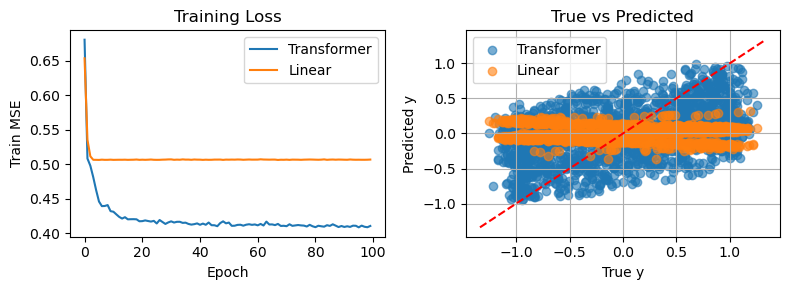

In [12]:
print("\nTraining Linear Regression...")
linear_model = LinearRegression(input_dim=input_dim)
linear_losses, linear_mse, linear_preds, linear_targets, linear_time = train_model(linear_model, train_loader, test_loader, n_epochs = 100, lr = 1e-2)

# --- 5. Print and Plot Results ---
print(f"\nTransformer Test MSE: {transformer_mse:.4f}, Time: {transformer_time:.2f}s")
print(f"Linear     Test MSE: {linear_mse:.4f}, Time: {linear_time:.2f}s")

# Plot losses
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(transformer_losses, label="Transformer")
plt.plot(linear_losses, label="Linear")
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.title("Training Loss")
plt.legend()

# Plot predictions
plt.subplot(1, 2, 2)
plt.scatter(transformer_targets.numpy(), transformer_preds.numpy(), label="Transformer", alpha=0.6)
plt.scatter(linear_targets.numpy(), linear_preds.numpy(), label="Linear", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("True vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()